# Demo PhoBERT ABSA
Load checkpoint tot nhat, predict aspect-level sentiment, so sanh SFT vs PPO.

In [1]:
!pip install -q torchao --upgrade
!pip install -q --upgrade transformers peft accelerate sentencepiece
!pip install -q torch pyvi pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 141.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 84.1 MB/s eta 0:00:00


In [2]:
import json, os, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
from sklearn.metrics import classification_report, f1_score
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import torch.nn.functional as F
from torch.distributions import Categorical

In [4]:
SEED = 42
MODEL_NAME = "vinai/phobert-base"
MAX_LEN = 256
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ASPECT_COLS = [
    "FACILITIES#CLEANLINESS","FACILITIES#COMFORT","FACILITIES#DESIGN&FEATURES","FACILITIES#GENERAL",
    "FACILITIES#MISCELLANEOUS","FACILITIES#PRICES","FACILITIES#QUALITY","FOOD&DRINKS#MISCELLANEOUS",
    "FOOD&DRINKS#PRICES","FOOD&DRINKS#QUALITY","FOOD&DRINKS#STYLE&OPTIONS","HOTEL#CLEANLINESS",
    "HOTEL#COMFORT","HOTEL#DESIGN&FEATURES","HOTEL#GENERAL","HOTEL#MISCELLANEOUS","HOTEL#PRICES",
    "HOTEL#QUALITY","LOCATION#GENERAL","ROOMS#CLEANLINESS","ROOMS#COMFORT","ROOMS#DESIGN&FEATURES",
    "ROOMS#GENERAL","ROOMS#MISCELLANEOUS","ROOMS#PRICES","ROOMS#QUALITY","ROOM_AMENITIES#CLEANLINESS",
    "ROOM_AMENITIES#COMFORT","ROOM_AMENITIES#DESIGN&FEATURES","ROOM_AMENITIES#GENERAL",
    "ROOM_AMENITIES#MISCELLANEOUS","ROOM_AMENITIES#PRICES","ROOM_AMENITIES#QUALITY","SERVICE#GENERAL",
]
LABEL_NAMES = ["None", "Positive", "Negative", "Neutral"]
N_POLARITIES = len(LABEL_NAMES)
N_ASPECTS    = len(ASPECT_COLS)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Device: {DEVICE}")

Device: cuda


In [5]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR  = Path("/content/drive/MyDrive/task2_dataset")
SAVE_PATH = Path("/content/drive/MyDrive/ABSA_Task2")
SAVE_PATH.mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR : {DATA_DIR}")
print(f"SAVE_PATH: {SAVE_PATH}")

Mounted at /content/drive
DATA_DIR : /content/drive/MyDrive/task2_dataset
SAVE_PATH: /content/drive/MyDrive/ABSA_Task2


In [6]:
# LoRA r=16 target query+key+value (capacity lon hon r=8/qv) - bat buoc giong nhau
# giua Stage 1, 2, 3 vi checkpoint phai compatible.
LORA_R           = 16
LORA_ALPHA       = 32
LORA_TARGETS     = ["query", "key", "value"]
LORA_DROPOUT     = 0.1
HEAD_DROPOUT     = 0.2

def build_lora_backbone():
    phobert = AutoModel.from_pretrained(MODEL_NAME)
    return get_peft_model(phobert, LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, target_modules=LORA_TARGETS,
        lora_dropout=LORA_DROPOUT, bias="none"))

class PhoBertACSA_LoRA(nn.Module):
    def __init__(self):
        super().__init__()
        self.phobert    = build_lora_backbone()
        self.dropout    = nn.Dropout(HEAD_DROPOUT)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS * N_POLARITIES)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        return self.classifier(pooled).view(-1, N_ASPECTS, N_POLARITIES)

class PhoBertACSA_ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.phobert    = build_lora_backbone()
        self.dropout    = nn.Dropout(HEAD_DROPOUT)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS * N_POLARITIES)
        self.critic     = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        logits = self.classifier(pooled).view(-1, N_ASPECTS, N_POLARITIES)
        values = self.critic(pooled)
        return logits, values

In [7]:
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer):
        texts = df["Review"].fillna("").astype(str).tolist()
        tokenized = [ViTokenizer.tokenize(t.lower()) for t in texts]
        self.encodings = tokenizer(tokenized, truncation=True, add_special_tokens=True,
                                   max_length=MAX_LEN, padding="max_length")
        self.labels = df[ASPECT_COLS].astype("int64").to_numpy()
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i], dtype=torch.long) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

def make_loader(df, tokenizer, shuffle=False):
    return DataLoader(ABSADataset(df, tokenizer), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=0, pin_memory=True)

def compute_metrics(y_true, y_pred):
    ft, fp = y_true.reshape(-1), y_pred.reshape(-1)
    m = {
        "flat_macro_f1": f1_score(ft, fp, labels=list(range(N_POLARITIES)), average="macro", zero_division=0),
        "exact_match":   float(np.mean(np.all(y_true == y_pred, axis=1))),
    }
    mask = ft != 0
    m["non_none_macro_f1"]   = f1_score(ft[mask], fp[mask], labels=[1,2,3], average="macro", zero_division=0) if mask.any() else 0.0
    m["per_aspect_macro_f1"] = float(np.mean([
        f1_score(y_true[:,a], y_pred[:,a], labels=list(range(N_POLARITIES)), average="macro", zero_division=0)
        for a in range(y_true.shape[1])]))
    return m

@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    model.eval()
    all_labels, all_preds, total_loss = [], [], 0.0
    for batch in loader:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        out    = model(ids, mask)
        logits = out[0] if isinstance(out, tuple) else out
        if criterion:
            total_loss += criterion(logits.reshape(-1, N_POLARITIES), labels.reshape(-1)).item()
        all_labels.append(labels.cpu().numpy())
        all_preds.append(logits.argmax(-1).cpu().numpy())
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    m = compute_metrics(y_true, y_pred)
    if criterion:
        m["loss"] = total_loss / max(len(loader), 1)
    m["y_true"] = y_true; m["y_pred"] = y_pred
    return m

def print_metrics(prefix, m):
    keys = ["loss","flat_macro_f1","non_none_macro_f1","per_aspect_macro_f1","exact_match"]
    parts = [f"{k}: {m[k]:.4f}" for k in keys if k in m]
    print(f"{prefix} | " + " | ".join(parts))

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def load_model(cls, path):
    m = cls().to(DEVICE)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.eval(); return m

models = {}
for name, path, cls in [
    ("PPO",          SAVE_PATH/"final_ppo_model.bin",         PhoBertACSA_ActorCritic),
    ("Actor-Critic", SAVE_PATH/"actor_critic_pretrained.bin", PhoBertACSA_ActorCritic),
    ("SFT",          SAVE_PATH/"best_model_sft.bin",          PhoBertACSA_LoRA),
]:
    if path.exists():
        models[name] = load_model(cls, path)
        print(f"Loaded {name}")

if not models:
    raise FileNotFoundError("Khong co checkpoint nao. Chay Stage 1/2/3 truoc.")
primary = next(iter(models))
print(f"Primary: {primary}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loaded Actor-Critic


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded SFT
Primary: PPO


In [9]:
@torch.no_grad()
def predict_proba(model, review):
    text = ViTokenizer.tokenize(str(review).lower())
    enc  = tokenizer(text, truncation=True, add_special_tokens=True,
                     max_length=MAX_LEN, padding="max_length", return_tensors="pt")
    out  = model(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
    logits = out[0] if isinstance(out, tuple) else out
    return torch.softmax(logits, dim=-1)[0].cpu().numpy()

def predict_df(review, model_name=None, top_k=8, show_none=False):
    probs    = predict_proba(models[model_name or primary], review)
    pred_ids = probs.argmax(axis=-1)
    rows = []
    for aspect, pid, ap in zip(ASPECT_COLS, pred_ids, probs):
        if pid == 0 and not show_none: continue
        rows.append({"aspect": aspect, "sentiment": LABEL_NAMES[int(pid)],
                     "conf": round(float(ap[pid]),4),
                     "P(Pos)": round(float(ap[1]),4),
                     "P(Neg)": round(float(ap[2]),4),
                     "P(Neu)": round(float(ap[3]),4)})
    rows.sort(key=lambda r: r["conf"], reverse=True)
    return pd.DataFrame(rows[:top_k])

def show(review, gt=None, top_k=8):
    from IPython.display import display
    print(f"Review: {review}")
    display(predict_df(review, top_k=top_k))
    if gt is not None:
        gt_rows = [{"aspect":a,"true":LABEL_NAMES[int(gt[a])]} for a in ASPECT_COLS if int(gt[a])!=0]
        print("Ground truth:"); display(pd.DataFrame(gt_rows))

In [10]:
# Tập demo đa dạng theo nhiều kịch bản (tiếng Việt có dấu đầy đủ)
demo_reviews = [
    # 1. Toàn positive
    ("Tất cả tích cực",
     "Khách sạn tuyệt vời, phòng cực kỳ sạch sẽ, nhân viên thân thiện và chuyên nghiệp, "
     "đồ ăn ngon, vị trí thuận tiện, giá cả hợp lý. Tôi sẽ quay lại lần sau."),

    # 2. Toàn negative
    ("Tất cả tiêu cực",
     "Phòng quá nhỏ và bẩn, điều hòa không hoạt động, nhân viên thô lỗ, "
     "đồ ăn dở, wifi chậm, giá thì đắt. Tôi sẽ không bao giờ quay lại."),

    # 3. Mixed - khen chê cân bằng
    ("Vừa khen vừa chê",
     "Vị trí rất thuận tiện gần biển, view phòng đẹp tuyệt vời. "
     "Tuy nhiên phòng ồn vào ban đêm, điều hòa hoạt động kém, bữa sáng hơi ít món."),

    # 4. Focus: phòng & tiện nghi
    ("Tập trung phòng",
     "Phòng rộng rãi, giường êm, chăn ga sạch sẽ, ban công đẹp. "
     "Nhưng tủ lạnh hỏng, TV cũ, wifi rất yếu không xem được phim."),

    # 5. Focus: vị trí
    ("Tập trung vị trí",
     "Khách sạn nằm ngay trung tâm, đi bộ ra phố cổ chỉ 5 phút, gần chợ đêm và các điểm du lịch. "
     "Xung quanh có nhiều quán ăn ngon và tiện lợi."),

    # 6. Focus: dịch vụ / nhân viên
    ("Tập trung dịch vụ",
     "Lễ tân nói tiếng Anh tốt, check-in nhanh chóng, nhân viên dọn phòng tận tình, "
     "concierge nhiệt tình tư vấn tour. Dịch vụ phòng 24/7."),

    # 7. Focus: đồ ăn
    ("Tập trung đồ ăn",
     "Bữa sáng buffet phong phú đa dạng, món Việt và món Âu đều ngon. "
     "Nhà hàng trong khách sạn có thực đơn sang trọng, giá hơi cao."),

    # 8. Focus: facilities (hồ bơi, gym, spa)
    ("Tập trung tiện ích",
     "Hồ bơi rộng và sạch, phòng gym đầy đủ dụng cụ hiện đại, spa thư giãn tuyệt vời. "
     "Bãi đỗ xe rộng rãi miễn phí cho khách."),

    # 9. Focus: vệ sinh / sạch sẽ
    ("Tập trung vệ sinh",
     "Phòng sạch sẽ thơm tho, drap giường được thay mỗi ngày, nhà tắm khô ráo. "
     "Khu vực công cộng cũng được lau chùi kỹ lưỡng."),

    # 10. Focus: giá cả
    ("Tập trung giá cả",
     "Giá phòng rất hợp lý so với chất lượng, có nhiều ưu đãi cho khách ở dài hạn. "
     "Nhà hàng hơi đắt nhưng đồ ăn xứng đáng đồng tiền."),

    # 11. Neutral / tạm được
    ("Trung tính",
     "Khách sạn bình thường, không có gì nổi bật. Phòng tạm chấp nhận được, "
     "dịch vụ ở mức trung bình, giá ngang ngửa các nơi khác."),

    # 12. Review ngắn
    ("Review ngắn",
     "Phòng sạch, nhân viên tốt, đáng đồng tiền."),

    # 13. Phòng ồn điều hòa kém
    ("Phòng ồn",
     "Khách sạn nằm mặt đường lớn nên rất ồn vào ban đêm, khó ngủ. "
     "Điều hòa cũ phát ra tiếng ồn lớn, nhân viên không xử lý khi phản ánh."),

    # 14. Khen nhiều chê 1 thứ
    ("Khen nhiều chê 1",
     "Khách sạn đẹp, phòng sang trọng, nhân viên chuyên nghiệp, vị trí tuyệt vời, "
     "đồ ăn ngon... nhưng wifi chậm hơn cả 3G điện thoại!"),

    # 15. Chê nhiều khen 1
    ("Chê nhiều khen 1",
     "Phòng cũ và ẩm mốc, điều hòa kém, bữa sáng đơn điệu, nhân viên không thân thiện. "
     "Điểm cộng duy nhất là vị trí gần biển."),

    # 16. Cảm xúc mạnh tích cực
    ("Cảm xúc mạnh tích cực",
     "Quá tuyệt vời! Đây là khách sạn tốt nhất tôi từng ở, mọi thứ đều hoàn hảo từ phòng đến dịch vụ!"),

    # 17. Cảm xúc mạnh tiêu cực
    ("Cảm xúc mạnh tiêu cực",
     "Thất vọng tràn trề! Phòng kinh khủng, dịch vụ tệ hại, không xứng với số tiền tôi bỏ ra."),

    # 18. Long detailed review
    ("Review dài chi tiết",
     "Tôi đặt phòng ở đây 3 đêm. Vị trí rất thuận tiện, gần bãi biển và các quán ăn. "
     "Phòng rộng rãi, sạch sẽ, giường êm và đầy đủ tiện nghi. Tuy nhiên hệ thống wifi "
     "khá chậm và không ổn định. Nhân viên lễ tân thân thiện và biết tiếng Anh tốt. "
     "Bữa sáng đa dạng nhưng không có nhiều món Việt. Hồ bơi đẹp, sạch sẽ. Tổng thể đáng tiền."),
]

for label, review in demo_reviews:
    print(f"### {label}")
    show(review)
    print("-" * 100)

### Tất cả tích cực
Review: Khách sạn tuyệt vời, phòng cực kỳ sạch sẽ, nhân viên thân thiện và chuyên nghiệp, đồ ăn ngon, vị trí thuận tiện, giá cả hợp lý. Tôi sẽ quay lại lần sau.


,aspect,sentiment,conf,P(Pos),P(Neg),P(Neu)
0,HOTEL#COMFORT,Positive,0.7204,0.7204,0.1256,0.0680
1,HOTEL#GENERAL,Positive,0.6405,0.6405,0.1294,0.1421
2,SERVICE#GENERAL,Positive,0.6129,0.6129,0.1783,0.1537
3,HOTEL#DESIGN&FEATURES,Positive,0.6057,0.6057,0.1868,0.1161
4,FOOD&DRINKS#STYLE&OPTIONS,Negative,0.5867,0.1900,0.5867,0.1190
5,LOCATION#GENERAL,Positive,0.5413,0.5413,0.2584,0.1144
6,ROOMS#CLEANLINESS,Positive,0.5232,0.5232,0.2164,0.1194
7,HOTEL#PRICES,Positive,0.5018,0.5018,0.1957,0.1377


----------------------------------------------------------------------------------------------------
### Tất cả tiêu cực
Review: Phòng quá nhỏ và bẩn, điều hòa không hoạt động, nhân viên thô lỗ, đồ ăn dở, wifi chậm, giá thì đắt. Tôi sẽ không bao giờ quay lại.


,aspect,sentiment,conf,P(Pos),P(Neg),P(Neu)
0,HOTEL#COMFORT,Positive,0.6779,0.6779,0.1416,0.0672
1,HOTEL#GENERAL,Positive,0.6133,0.6133,0.1478,0.1488
2,HOTEL#DESIGN&FEATURES,Positive,0.5925,0.5925,0.1833,0.1337
3,FOOD&DRINKS#STYLE&OPTIONS,Negative,0.5612,0.2124,0.5612,0.1133
4,SERVICE#GENERAL,Positive,0.5588,0.5588,0.1957,0.1778
5,LOCATION#GENERAL,Positive,0.5226,0.5226,0.2562,0.1343
6,HOTEL#PRICES,Positive,0.4995,0.4995,0.1967,0.1387
7,ROOMS#CLEANLINESS,Positive,0.4957,0.4957,0.2507,0.1293


----------------------------------------------------------------------------------------------------
### Vừa khen vừa chê
Review: Vị trí rất thuận tiện gần biển, view phòng đẹp tuyệt vời. Tuy nhiên phòng ồn vào ban đêm, điều hòa hoạt động kém, bữa sáng hơi ít món.


...

----------------------------------------------------------------------------------------------------
### Cảm xúc mạnh tiêu cực
Review: Thất vọng tràn trề! Phòng kinh khủng, dịch vụ tệ hại, không xứng với số tiền tôi bỏ ra.


,aspect,sentiment,conf,P(Pos),P(Neg),P(Neu)
0,HOTEL#DESIGN&FEATURES,Positive,0.5916,0.5916,0.1651,0.1499
1,HOTEL#GENERAL,Positive,0.5733,0.5733,0.1384,0.1755
2,HOTEL#COMFORT,Positive,0.5679,0.5679,0.1723,0.1098
3,SERVICE#GENERAL,Positive,0.5616,0.5616,0.1948,0.1637
4,FOOD&DRINKS#STYLE&OPTIONS,Negative,0.5399,0.1944,0.5399,0.1260
5,HOTEL#PRICES,Positive,0.5265,0.5265,0.1838,0.1131
6,LOCATION#GENERAL,Positive,0.5172,0.5172,0.2465,0.1246
7,ROOMS#CLEANLINESS,Positive,0.4318,0.4318,0.2328,0.1861


----------------------------------------------------------------------------------------------------
### Review dài chi tiết
Review: Tôi đặt phòng ở đây 3 đêm. Vị trí rất thuận tiện, gần bãi biển và các quán ăn. Phòng rộng rãi, sạch sẽ, giường êm và đầy đủ tiện nghi. Tuy nhiên hệ thống wifi khá chậm và không ổn định. Nhân viên lễ tân thân thiện và biết tiếng Anh tốt. Bữa sáng đa dạng nhưng không có nhiều món Việt. Hồ bơi đẹp, sạch sẽ. Tổng thể đáng tiền.


,aspect,sentiment,conf,P(Pos),P(Neg),P(Neu)
0,HOTEL#COMFORT,Positive,0.7402,0.7402,0.1151,0.0502
1,HOTEL#GENERAL,Positive,0.6505,0.6505,0.1099,0.1731
2,FOOD&DRINKS#STYLE&OPTIONS,Negative,0.6503,0.1618,0.6503,0.1101
3,SERVICE#GENERAL,Positive,0.5973,0.5973,0.1897,0.1554
4,LOCATION#GENERAL,Positive,0.5950,0.5950,0.2211,0.1130
5,HOTEL#DESIGN&FEATURES,Positive,0.5436,0.5436,0.2388,0.1292
6,ROOM_AMENITIES#QUALITY,Negative,0.5261,0.1395,0.5261,0.1251
7,ROOMS#CLEANLINESS,Positive,0.5029,0.5029,0.2475,0.0975


----------------------------------------------------------------------------------------------------


In [12]:
def compare(review, top_k=6):
    from IPython.display import display
    print(f"Review: {review}\n")
    for name in models:
        print(f"[{name}]"); display(predict_df(review, model_name=name, top_k=top_k))
    print("-"*100)

# So sanh tren 1 review co dau day du
if len(models) > 1:
    compare(demo_reviews[2][1])  # review mixed
else:
    print(f"Chi co {list(models)} - chay them stage de so sanh.")

Review: Vị trí rất thuận tiện gần biển, view phòng đẹp tuyệt vời. Tuy nhiên phòng ồn vào ban đêm, điều hòa hoạt động kém, bữa sáng hơi ít món.

[PPO]


,aspect,sentiment,conf,P(Pos),P(Neg),P(Neu)
0,HOTEL#COMFORT,Positive,0.7113,0.7113,0.1272,0.0594
1,FOOD&DRINKS#STYLE&OPTIONS,Negative,0.6607,0.1434,0.6607,0.1018
2,HOTEL#GENERAL,Positive,0.6464,0.6464,0.0967,0.1835
3,SERVICE#GENERAL,Positive,0.6199,0.6199,0.1949,0.1294
4,LOCATION#GENERAL,Positive,0.5532,0.5532,0.2465,0.1187
5,ROOMS#CLEANLINESS,Positive,0.5462,0.5462,0.2202,0.1108


[Actor-Critic]


,aspect,sentiment,conf,P(Pos),P(Neg),P(Neu)
0,HOTEL#COMFORT,Positive,0.7113,0.7113,0.1272,0.0594
1,FOOD&DRINKS#STYLE&OPTIONS,Negative,0.6607,0.1434,0.6607,0.1018
2,HOTEL#GENERAL,Positive,0.6464,0.6464,0.0967,0.1835
3,SERVICE#GENERAL,Positive,0.6199,0.6199,0.1949,0.1294
4,LOCATION#GENERAL,Positive,0.5532,0.5532,0.2465,0.1187
5,ROOMS#CLEANLINESS,Positive,0.5462,0.5462,0.2202,0.1108


[SFT]


,aspect,sentiment,conf,P(Pos),P(Neg),P(Neu)
0,HOTEL#COMFORT,Positive,0.7113,0.7113,0.1272,0.0594
1,FOOD&DRINKS#STYLE&OPTIONS,Negative,0.6607,0.1434,0.6607,0.1018
2,HOTEL#GENERAL,Positive,0.6464,0.6464,0.0967,0.1835
3,SERVICE#GENERAL,Positive,0.6199,0.6199,0.1949,0.1294
4,LOCATION#GENERAL,Positive,0.5532,0.5532,0.2465,0.1187
5,ROOMS#CLEANLINESS,Positive,0.5462,0.5462,0.2202,0.1108


----------------------------------------------------------------------------------------------------


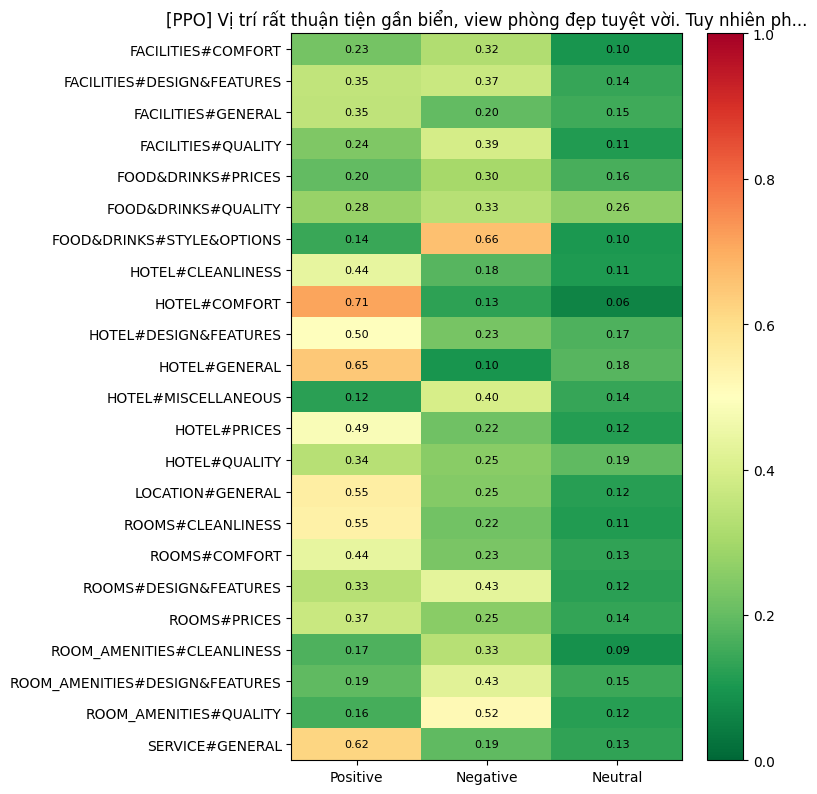

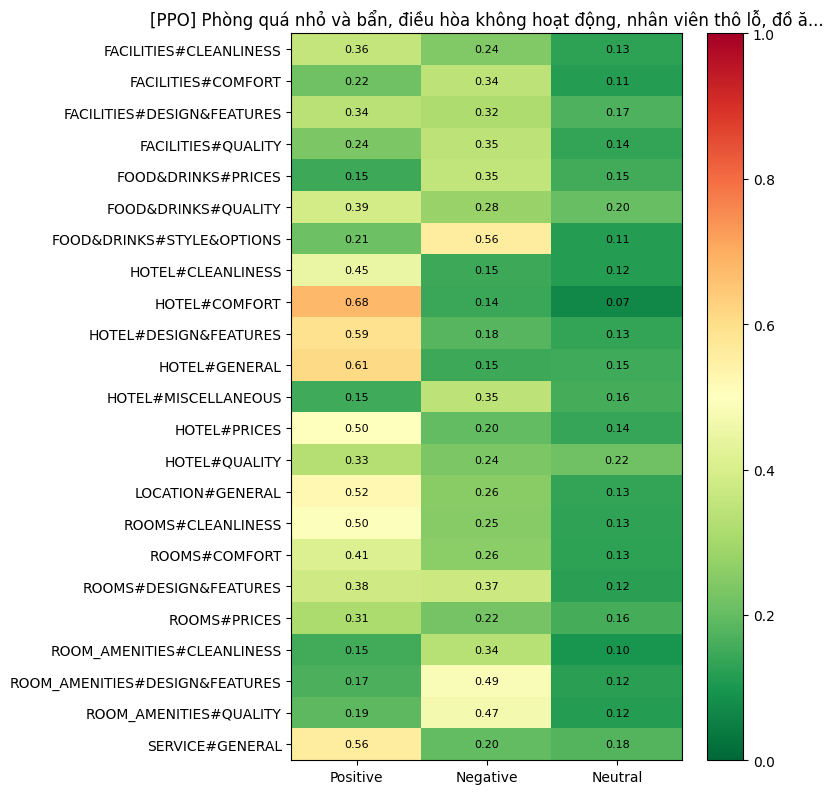

In [13]:
def heatmap(review, model_name=None, threshold=0.3):
    probs = predict_proba(models[model_name or primary], review)
    keep  = probs[:,1:].max(axis=1) > threshold
    if not keep.any(): print("Khong co aspect nao > threshold."); return
    aspects = [a for a,k in zip(ASPECT_COLS, keep) if k]
    p = probs[keep][:,1:]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.35*len(aspects))))
    im = ax.imshow(p, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(LABEL_NAMES[1:])
    ax.set_yticks(range(len(aspects))); ax.set_yticklabels(aspects)
    for i in range(len(aspects)):
        for j in range(3):
            ax.text(j, i, f"{p[i,j]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax)
    ax.set_title(f"[{model_name or primary}] {review[:70]}{'...' if len(review)>70 else ''}")
    plt.tight_layout(); plt.show()

heatmap(demo_reviews[2][1])  # review mixed
heatmap(demo_reviews[1][1])  # toan negative

In [14]:
test_df = pd.read_csv(DATA_DIR / "3-VLSP2018-SA-Hotel-test.csv")
sample  = test_df.sample(1, random_state=SEED).iloc[0]
show(sample["Review"], gt=sample, top_k=10)

Review: Bạn cùng phòng dễ thương cực kỳ Chỗ tắm chung có thể sạch hơn một chút thì tốt quá


,aspect,sentiment,conf,P(Pos),P(Neg),P(Neu)
0,HOTEL#GENERAL,Positive,0.5962,0.5962,0.1213,0.1958
1,HOTEL#COMFORT,Positive,0.5844,0.5844,0.1512,0.1174
2,SERVICE#GENERAL,Positive,0.5676,0.5676,0.1735,0.1858
3,ROOM_AMENITIES#QUALITY,Negative,0.5242,0.1458,0.5242,0.1356
4,FOOD&DRINKS#STYLE&OPTIONS,Negative,0.5194,0.2006,0.5194,0.1375
5,ROOMS#CLEANLINESS,Positive,0.4948,0.4948,0.2336,0.1555
6,HOTEL#DESIGN&FEATURES,Positive,0.4914,0.4914,0.2350,0.1531
7,LOCATION#GENERAL,Positive,0.4542,0.4542,0.2788,0.1495
8,HOTEL#PRICES,Positive,0.4259,0.4259,0.2359,0.1767
9,HOTEL#CLEANLINESS,Positive,0.4000,0.4000,0.2093,0.1085


Ground truth:


,aspect,true
0,ROOMS#MISCELLANEOUS,Positive
1,ROOM_AMENITIES#CLEANLINESS,Negative


In [15]:
test_loader = make_loader(test_df, tokenizer)
test_m = evaluate_model(models[primary], test_loader)
print_metrics(f"[{primary}] Test", test_m)

[PPO] Test | flat_macro_f1: 0.2387 | non_none_macro_f1: 0.4463 | per_aspect_macro_f1: 0.1355 | exact_match: 0.0000
